In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from umap import UMAP


sns.set_theme(style="ticks", context="notebook", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 1.2

/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# df = pd.read_csv('alkynes_smi.csv')
# df.head()

In [3]:
# from aqme.qdescp import qdescp
#
# qdescp(
#     program='xtb',
#     input='alkynes_smi.csv',
#     qdescp_atoms=['C#C'],
#     nproc=63
# )

In [2]:
alkynes_df =  pd.read_csv("./AQME_full_alkynes_smi.csv")
alkynes_df

,SMILES,code_name,C#C_max_Partial charge,C#C_max_Atom SASA,C#C_max_Buried volume,C#C_max_H bond H2O,C#C_max_Fukui+,C#C_max_Fukui-,C#C_max_Electrophil.,C#C_max_Normaliz. electrophil.,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,C#CC(=O)C(C)C,1,0.0324,46.8012,49.3465,0.0,0.1444,0.0754,0.0513,0.1243,...,0,0,0,1,0,0,0,0,0,0
1,C#CC(=O)C(OCC)OCC,2,0.0481,48.4693,49.9645,0.0,0.1440,0.0556,0.0539,0.1332,...,0,0,0,1,0,0,0,0,0,0
2,C#CC(=O)CC,3,0.0290,51.2457,44.7763,0.0,0.1476,0.0842,0.0529,0.1297,...,0,0,0,1,0,0,0,0,0,0
3,C#CC(=O)CCC,4,0.0307,50.5034,45.8163,0.0,0.1463,0.0703,0.0509,0.1244,...,0,0,0,1,0,0,0,0,0,0
4,C#CC(=O)CCc1ccccc1,5,0.0325,47.4112,48.8240,0.0,0.0979,0.0480,0.0394,0.0928,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,OCCC#Cc1ccccn1,1308,0.0249,14.9624,50.6671,0.0,0.1170,0.0509,0.0413,0.0901,...,0,0,0,0,0,0,0,0,0,0
1308,OCCC#Cc1cccnc1,1309,0.0211,14.6585,51.4351,0.0,0.1150,0.0568,0.0416,0.0899,...,0,0,0,0,0,0,0,0,0,0
1309,OCCC#Cc1ccncc1,1310,0.0282,14.7381,51.1654,0.0,0.1181,0.0486,0.0436,0.0988,...,0,0,0,0,0,0,0,0,0,0
1310,OCc1ccc(C#CC(F)(F)F)cc1,1311,0.0558,13.4000,51.3793,0.0,0.1249,0.0927,0.0578,0.1360,...,0,0,0,0,0,0,0,0,0,0


In [3]:
X_df = alkynes_df.set_index('SMILES').drop(columns='code_name')
X_df

,C#C_max_Partial charge,C#C_max_Atom SASA,C#C_max_Buried volume,C#C_max_H bond H2O,C#C_max_Fukui+,C#C_max_Fukui-,C#C_max_Electrophil.,C#C_max_Normaliz. electrophil.,C#C_max_Normaliz. nucleophil.,C#C_max_Fukui_rad,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
SMILES,,,,,,,,,,,,,,,,,,,,,
C#CC(=O)C(C)C,0.0324,46.8012,49.3465,0.0,0.1444,0.0754,0.0513,0.1243,-0.4727,0.1097,...,0,0,0,1,0,0,0,0,0,0
C#CC(=O)C(OCC)OCC,0.0481,48.4693,49.9645,0.0,0.1440,0.0556,0.0539,0.1332,-0.2460,0.0995,...,0,0,0,1,0,0,0,0,0,0
C#CC(=O)CC,0.0290,51.2457,44.7763,0.0,0.1476,0.0842,0.0529,0.1297,-0.6007,0.1157,...,0,0,0,1,0,0,0,0,0,0
C#CC(=O)CCC,0.0307,50.5034,45.8163,0.0,0.1463,0.0703,0.0509,0.1244,-0.4461,0.1083,...,0,0,0,1,0,0,0,0,0,0
C#CC(=O)CCc1ccccc1,0.0325,47.4112,48.8240,0.0,0.0979,0.0480,0.0394,0.0928,-0.2279,0.0727,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OCCC#Cc1ccccn1,0.0249,14.9624,50.6671,0.0,0.1170,0.0509,0.0413,0.0901,-0.3007,0.0844,...,0,0,0,0,0,0,0,0,0,0
OCCC#Cc1cccnc1,0.0211,14.6585,51.4351,0.0,0.1150,0.0568,0.0416,0.0899,-0.3341,0.0856,...,0,0,0,0,0,0,0,0,0,0
OCCC#Cc1ccncc1,0.0282,14.7381,51.1654,0.0,0.1181,0.0486,0.0436,0.0988,-0.3253,0.0837,...,0,0,0,0,0,0,0,0,0,0


In [4]:
from sklearn.preprocessing import scale

# standardize
X_df = pd.DataFrame(scale(X_df), index=X_df.index, columns=X_df.columns)

# drop zero-variance features
zero_std_cols = X_df.columns[X_df.std() == 0]
X_df = X_df[X_df.columns.difference(zero_std_cols)]

print(f"Dropping {len(zero_std_cols)} features {zero_std_cols}")

Dropping 48 features Index(['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'EState_VSA11',
       'NumAtomStereoCenters', 'NumBridgeheadAtoms', 'NumSpiroAtoms',
       'NumUnspecifiedAtomStereoCenters', 'fr_Ar_COO', 'fr_C_S', 'fr_HOCCN',
       'fr_Imine', 'fr_SH', 'fr_alkyl_carbamate', 'fr_allylic_oxid',
       'fr_amidine', 'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzodiazepine',
       'fr_diazo', 'fr_dihydropyridine', 'fr_epoxide', 'fr_guanido',
       'fr_hdrzine', 'fr_hdrzone', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam',
       'fr_nitrile', 'fr_nitro', 'fr_nitro_arom', 'fr_nitro_arom_nonortho',
       'fr_nitroso', 'fr_oxime', 'fr_phos_acid', 'fr_phos_ester',
       'fr_prisulfonamd', 'fr_quatN', 'fr_sulfide', 'fr_sulfonamd',
       'fr_sulfone', 'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan',
       'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea'],
      dtype='object')


In [5]:
# drop highly correlated features
df_corr = X_df.corr().abs()
upper = df_corr.where(np.triu(np.ones(df_corr.shape),k=1).astype(np.bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
X_df = X_df.drop(to_drop, axis=1)

print(f"Dropping {len(to_drop)} features {to_drop}")


Dropping 102 features ['BCUT2D_MWHI', 'BertzCT', 'C#C_max_Buried volume', 'C#C_max_Fukui+', 'C#C_max_Fukui_rad', 'C#C_max_Normaliz. electrophil.', 'C#C_max_Normaliz. nucleophil.', 'C#C_min_Atom FOD', 'C#C_min_Atom SASA', 'C#C_min_Atom dispersion', 'C#C_min_Buried volume', 'C#C_min_Coord. numbers', 'C#C_min_Dipole moment', 'C#C_min_Electrophil.', 'C#C_min_Fukui dual', 'C#C_min_Fukui+', 'C#C_min_Fukui-', 'C#C_min_Fukui_rad', 'C#C_min_H bond H2O', 'C#C_min_Normaliz. electrophil.', 'C#C_min_Normaliz. nucleophil.', 'Chi0n', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'Dispersion area', 'Dispersion volume', 'EA', 'EState_VSA1', 'Electrophilicity', 'ExactMolWt', 'Fermi-level', 'FpDensityMorgan2', 'FpDensityMorgan3', 'FractionCSP3', 'HOMO-LUMO gap', 'Hardness', 'HeavyAtomCount', 'HeavyAtomMolWt', 'IP', 'Kappa1', 'Kappa3', 'LUMO', 'LabuteASA', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsPartialCharge', 'MinPartialCharge', 'MolMR', 'MolWt', 'Nucleofugality',

In [6]:
print(X_df.shape)

(1312, 124)


In [7]:

dims = [50, 20, 15, 10, 5, 2]

dfs = {}

# UMAP section
n_neigh = np.int_(np.sqrt(X_df.shape[1]))
for dim in dims:
    key = f"umap{dim}"
    dfs[key] = pd.DataFrame(UMAP(
        n_components=dim, n_neighbors=n_neigh,random_state=0
    ).fit_transform(X_df), index=X_df.index)

# PCA section
pc = pd.DataFrame(PCA(n_components=None).fit_transform(X_df), index=X_df.index)
for dim in dims:
    key = f"pc{dim}"
    dfs[key] = pc.iloc[:, :dim]

/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/minico

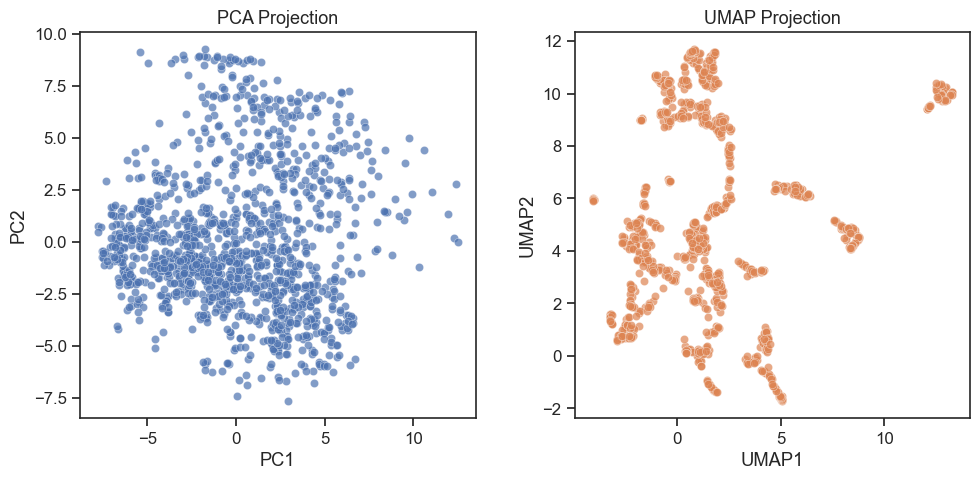

In [8]:


# =========================
# Data
# =========================
dfs['pc2'].columns = ['PC1', 'PC2']
dfs['umap2'].columns = ['UMAP1', 'UMAP2']

# =========================
# Figure
# =========================
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# PCA
sns.scatterplot(
    data=dfs['pc2'],
    x='PC1',
    y='PC2',
    s=35,
    alpha=0.7,
    color='#4C72B0',
    edgecolor='white',
    linewidth=0.3,
    ax=ax[0]
)

ax[0].set_title("PCA Projection", fontsize=13)
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

# UMAP
sns.scatterplot(
    data=dfs['umap2'],
    x='UMAP1',
    y='UMAP2',
    s=35,
    alpha=0.7,
    color='#DD8452',
    edgecolor='white',
    linewidth=0.3,
    ax=ax[1]
)

ax[1].set_title("UMAP Projection", fontsize=13)
ax[1].set_xlabel("UMAP1")
ax[1].set_ylabel("UMAP2")

# =========================
# Style polishing
# =========================
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
fig.savefig("../fig/AQME_1.svg", dpi=330)
fig.savefig("../fig/AQME_1.pdf", dpi=330)
plt.show()

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, fclusterdata
from sklearn.metrics import silhouette_score

# Define the numbeor of clusters to study
N_CLS_list = list(range(5, 41))
def silhouette_scores_hierarchical(data, n_cls_list):
    """helper function to compute a silhouette score for hierarchical cluster ing using Ward linkage"""
    z = linkage(data, method='ward')
    result = pd.Series(index=n_cls_list, dtype=float)
    for n_cls in n_cls_list:
        cls = fcluster(z, n_cls, criterion='maxclust')
        result.loc[n_cls] = silhouette_score(data, cls)
    return result

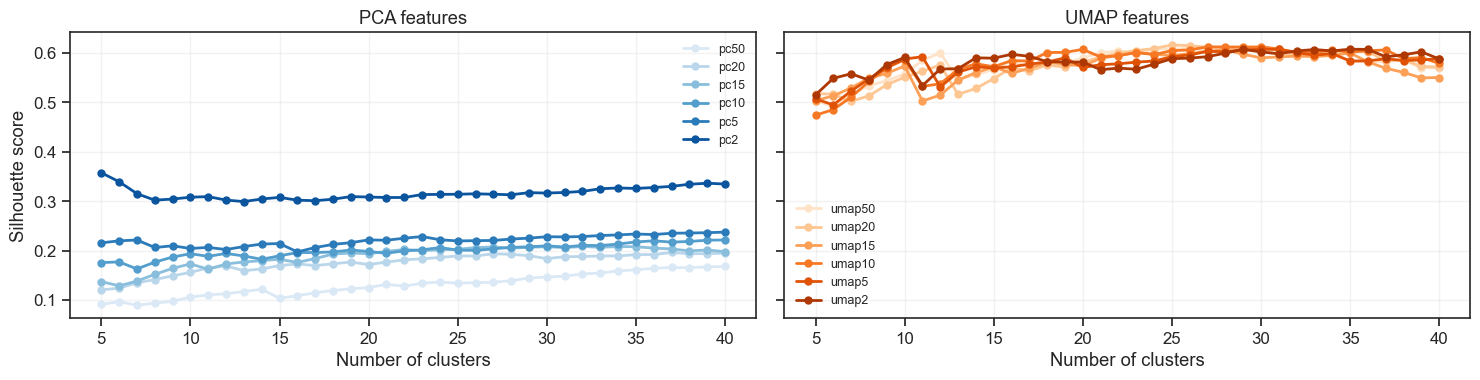

In [10]:
silh_scores = pd.DataFrame(index=N_CLS_list)

for key, value in dfs.items():
    silh_scores[key] = silhouette_scores_hierarchical(value, N_CLS_list)

# 分组
pca_cols = silh_scores.columns[silh_scores.columns.str.startswith("pc")]
umap_cols = silh_scores.columns[silh_scores.columns.str.startswith("umap")]

# =========================
# Plot
# =========================
fig, ax = plt.subplots(1, 2, figsize=(15, 4), sharey=True)

pca_palette = sns.color_palette("Blues", len(pca_cols))
umap_palette = sns.color_palette("Oranges", len(umap_cols))

# PCA
for i, col in enumerate(pca_cols):
    ax[0].plot(
        silh_scores.index,
        silh_scores[col],
        marker='o',
        linewidth=2,
        markersize=5,
        color=pca_palette[i],
        label=col
    )

ax[0].set_title("PCA features")
ax[0].set_xlabel("Number of clusters")
ax[0].set_ylabel("Silhouette score")
ax[0].legend(frameon=False, fontsize=9)

# UMAP
for i, col in enumerate(umap_cols):
    ax[1].plot(
        silh_scores.index,
        silh_scores[col],
        marker='o',
        linewidth=2,
        markersize=5,
        color=umap_palette[i],
        label=col
    )

ax[1].set_title("UMAP features")
ax[1].set_xlabel("Number of clusters")
ax[1].legend(frameon=False, fontsize=9)

# Style
for a in ax:
    a.grid(alpha=0.25)
plt.tight_layout()
fig.savefig("../fig/AQME_2.svg", dpi=330)
fig.savefig("../fig/AQME_2.pdf", dpi=330)
plt.show()

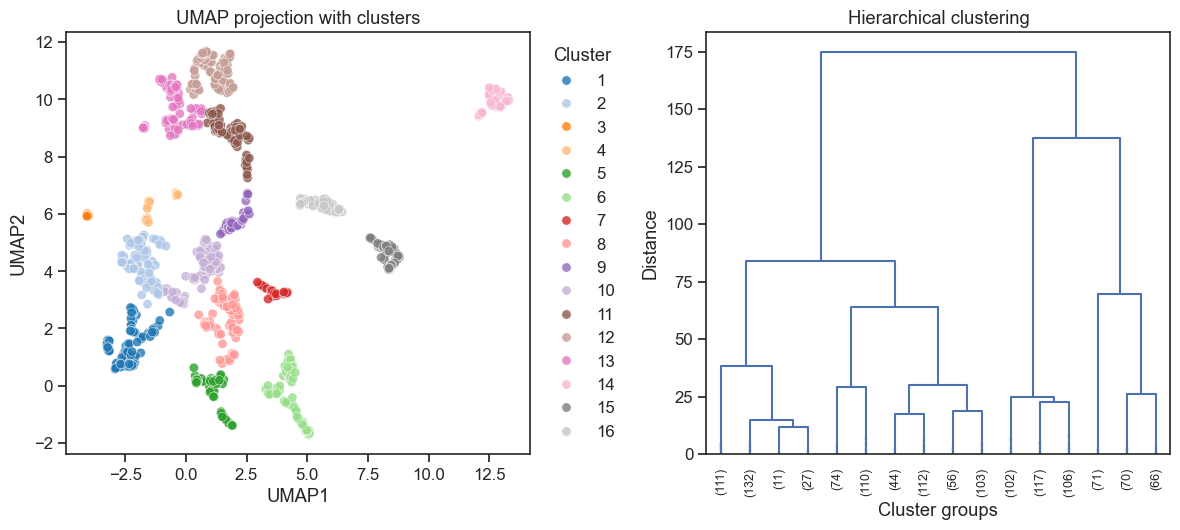

In [11]:
# final number of clusters to produce
NCLS = 16

# linkage and clustering for selected featurization
z = linkage(dfs['umap2'], method="ward")
cls = fcluster(z, NCLS, criterion='maxclust')

# plot the dendrogram
# =========================
# Subplots
# =========================
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))


# -------- UMAP scatter --------
palette = sns.color_palette("tab20", NCLS)

sns.scatterplot(
    x="UMAP1",
    y="UMAP2",
    data=dfs['umap2'],
    hue=cls,
    palette=palette,
    s=45,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.4,
    ax=ax[0]
)

ax[0].set_title("UMAP projection with clusters")
ax[0].set_xlabel("UMAP1")
ax[0].set_ylabel("UMAP2")

ax[0].legend(
    title="Cluster",
    bbox_to_anchor=(1.01,1),
    loc="upper left",
    frameon=False
)

# -------- dendrogram --------
dendrogram(
    z,
    truncate_mode='lastp',
    p=NCLS,
    show_contracted=True,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=0,
    ax=ax[1]
)

ax[1].set_title("Hierarchical clustering")
ax[1].set_xlabel("Cluster groups")
ax[1].set_ylabel("Distance")


# =========================
# Style polishing
# =========================
plt.tight_layout()
fig.savefig("../fig/AQME_3.svg", dpi=330)
fig.savefig("../fig/AQME_3.pdf", dpi=330)
plt.show()

In [12]:
target_smiles_dict = {
    "A1": 'C#Cc1ccc(F)cc1',
    "A2": 'C#Cc1ccc(C=O)cc1',
    "A3": 'C#Cc1ccc(CO)cc1',
    "A4": 'C#Cc1ccc(OC)cc1',
    "A5": 'C#Cc1ccc(C(C)(C)C)cc1',
    "A6": 'C#Cc1ccccc1',
    "A7": 'C#CC(C)(C)O',
    "A8": 'C#CCCO',
    "A9": 'C#CC(C)(C)C',
    "A10": 'C#CCCCCCC',
    "A11": 'C#CC1CCCCC1',
    "A12": 'CC#Cc1ccccc1',
    "A13": 'CC#CCC',
    "A14": 'CC#CCCCC',
    "A15": 'CC#CCCCCC',
    "A16": 'CCCCCC#CCO',
    "A17": 'CCCCCC#CCCl',
    "A18": 'CCC#CC(=O)O',
}

In [13]:
X_umap_df = dfs['umap2']
target_smiles = list(target_smiles_dict.values())
# 筛选出target分子的行
X_umap_target = X_umap_df[X_umap_df.index.isin(target_smiles)].copy()

# 1.4 补充mol_id和SMILES列（供悬停显示和分子绘制）
# 反向映射：SMILES → mol_id（A1-A18）
smiles_to_id = {v: k for k, v in target_smiles_dict.items()}
X_umap_target['SMILES'] = X_umap_target.index  # 索引是SMILES，赋值给SMILES列
X_umap_target['mol_id'] = X_umap_target['SMILES'].map(smiles_to_id)

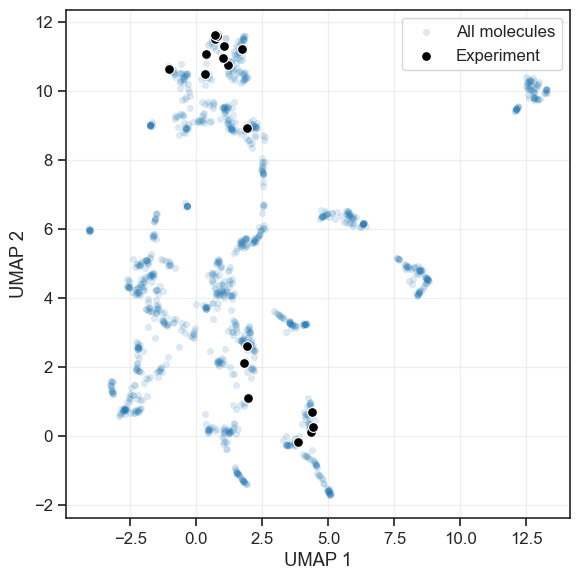

In [14]:
# ===================== 6. UMAP Plot =====================
plt.figure(figsize=(6, 6))

# 1. 绘制「所有分子」的散点（seaborn 方式）
sns.scatterplot(
    data=X_umap_df,    # 数据源
    x="UMAP1",         # x轴对应列名
    y="UMAP2",         # y轴对应列名
    s=20,              # 点的大小（和 plt.scatter 一致）
    alpha=0.15,        # 透明度
    label="All molecules",  # 图例标签
    color="tab:blue",  # 默认颜色（和 plt 默认一致）
    edgecolor=None     # 无外边框（原代码未设置）
)

# 2. 绘制「目标炔烃」的散点（叠加在原图上）
sns.scatterplot(
    data=X_umap_target,
    x="UMAP1",
    y="UMAP2",
    s=50,              # 更大的点
    color="black",   # 红色
    linewidth=0.8,     # 边框线宽
    alpha=1.0,         # 不透明（原代码未指定，默认1）
    label="Experiment"
)

# 3. 图表样式调整（和原代码保持一致）
plt.xlabel("UMAP 1")   # x轴标签
plt.ylabel("UMAP 2")   # y轴标签
plt.legend()           # 显示图例
plt.grid(alpha=0.3)    # 网格透明度
plt.tight_layout()     # 紧凑布局
plt.show()             # 显示图片

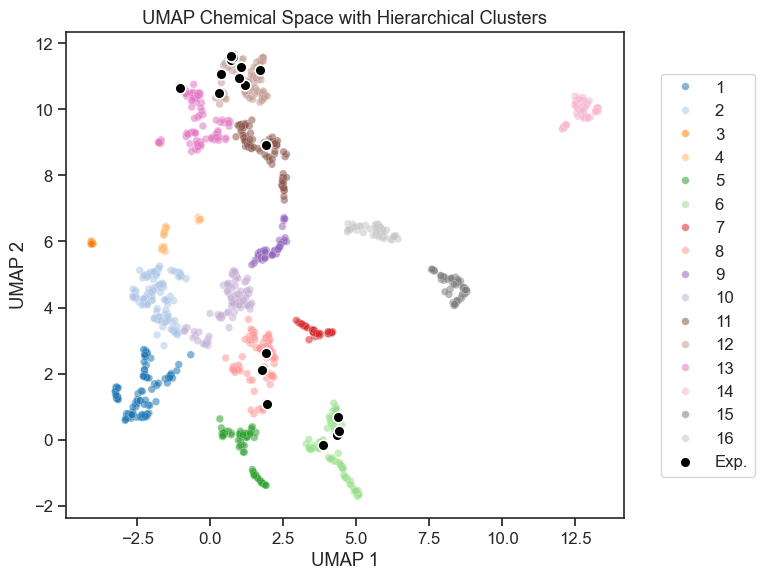

In [15]:
# =========================
# Clustering
# =========================
z = linkage(dfs['umap2'], method="ward")
cls = fcluster(z, NCLS, criterion='maxclust')

X_umap_df["cluster"] = cls

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(8,6))

palette = sns.color_palette("tab20", NCLS)

# 背景分子
sns.scatterplot(
    data=X_umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="cluster",
    palette=palette,
    s=30,
    alpha=0.55,
    edgecolor="white",
    linewidth=0.25,
    legend="full",
    ax=ax
)

# 实验分子 (target)
sns.scatterplot(
    data=X_umap_target,
    x="UMAP1",
    y="UMAP2",
    s=60,
    color="black",
    edgecolor="white",
    linewidth=1.2,
    label="Exp.",
    ax=ax
)

# =========================
# Labels
# =========================
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP Chemical Space with Hierarchical Clusters")


ax.legend(
    loc="center right",
    ncol=1,
    bbox_to_anchor=(1.25, 0.5)
    # 每行列数
)

plt.tight_layout()
fig.savefig("../fig/AQME_4.svg", dpi=330)
fig.savefig("../fig/AQME_4.pdf", dpi=330)
plt.show()

In [17]:
target_clusters = X_umap_df.loc[X_umap_target.index, "cluster"]
print(f"Target分子所属簇编号汇总：{np.unique(target_clusters)}")
print(f"每个Target分子的簇详情：\n{target_clusters}")

Target分子所属簇编号汇总：[ 6  8 11 12 13]
每个Target分子的簇详情：
SMILES
C#CC(C)(C)C              12
C#CC(C)(C)O              12
C#CC1CCCCC1              13
C#CCCCCCC                12
C#CCCO                   12
C#Cc1ccc(C(C)(C)C)cc1     6
C#Cc1ccc(C=O)cc1          8
C#Cc1ccc(CO)cc1           8
C#Cc1ccc(F)cc1            6
C#Cc1ccc(OC)cc1           8
C#Cc1ccccc1               6
CC#CCC                   12
CC#CCCCC                 12
CC#CCCCCC                12
CC#Cc1ccccc1              6
CCC#CC(=O)O              11
CCCCCC#CCCl              12
CCCCCC#CCO               12
Name: cluster, dtype: int32


Cluster 1, n molecules: 111


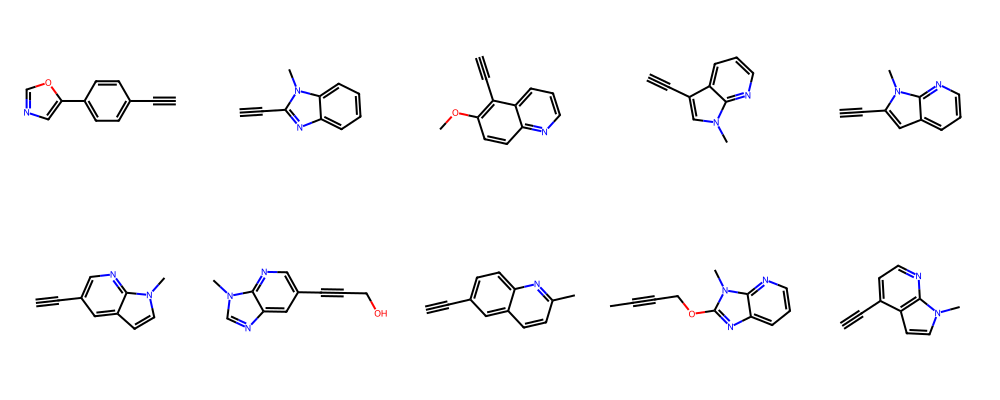

Cluster 2, n molecules: 132


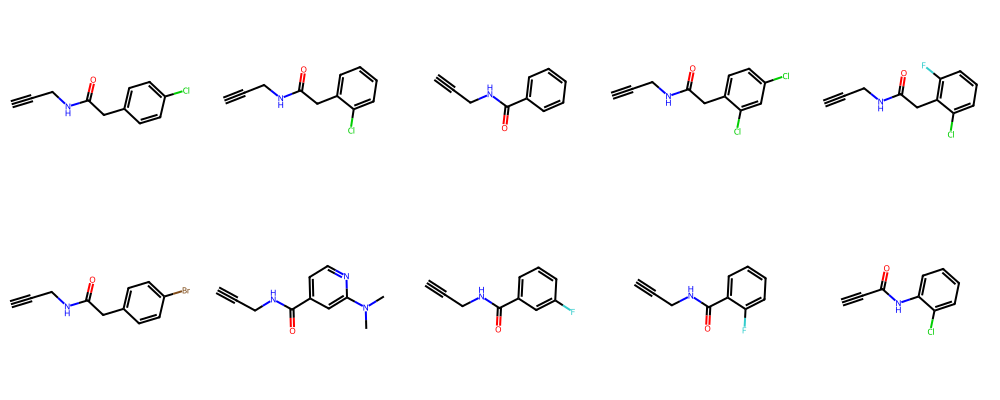

Cluster 3, n molecules: 11


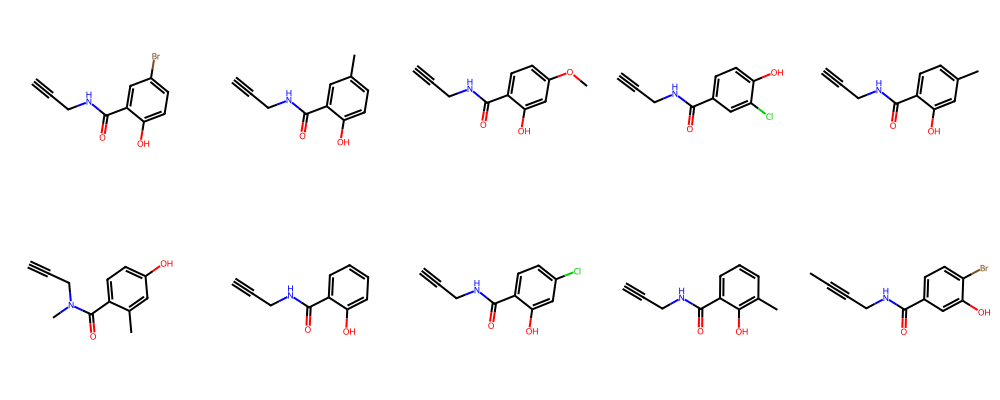

Cluster 4, n molecules: 27


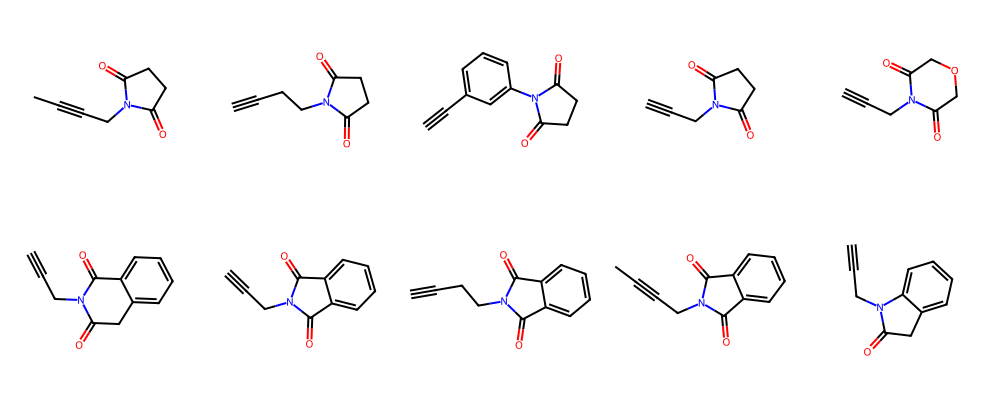

Cluster 5, n molecules: 74


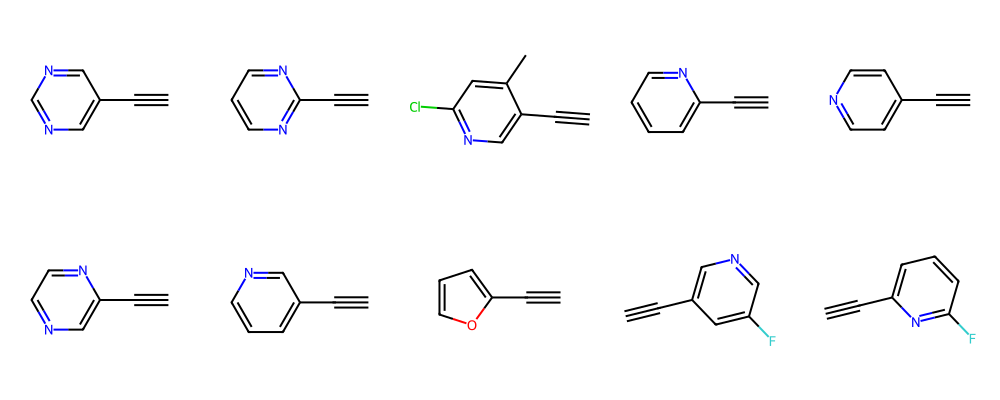

Cluster 6, n molecules: 110


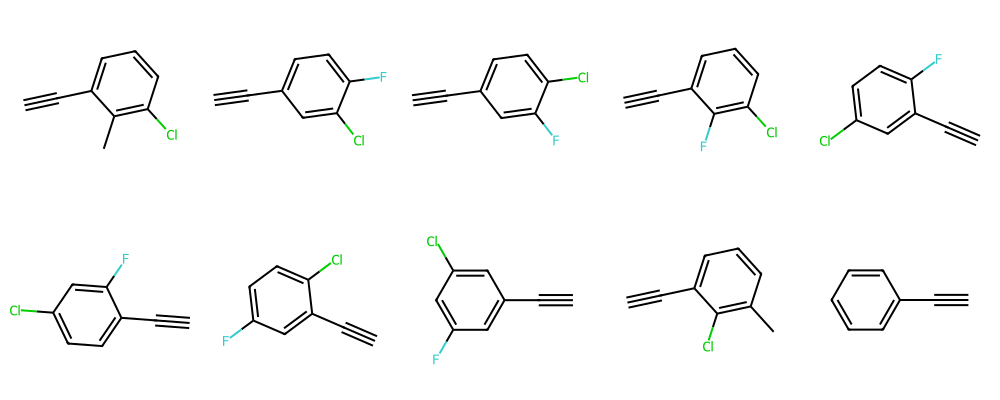

Cluster 7, n molecules: 44


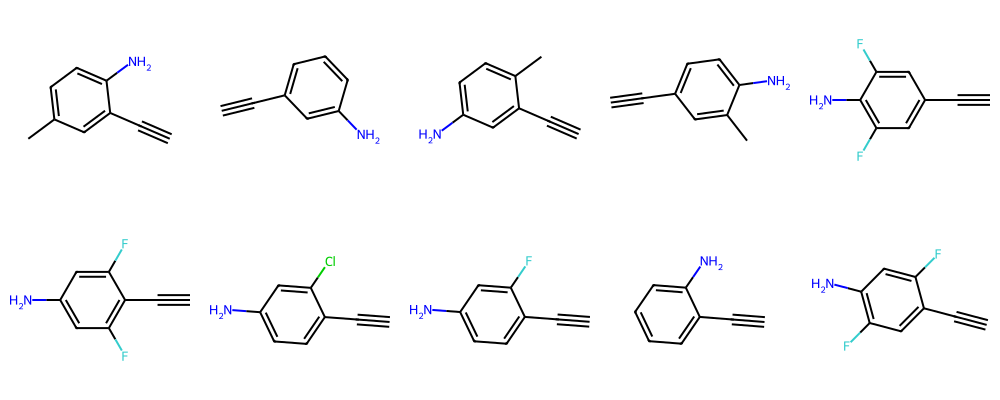

Cluster 8, n molecules: 112


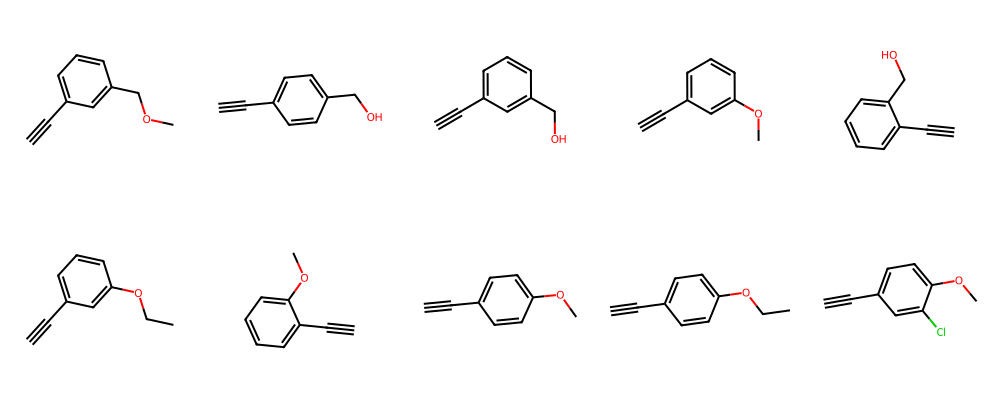

Cluster 9, n molecules: 56


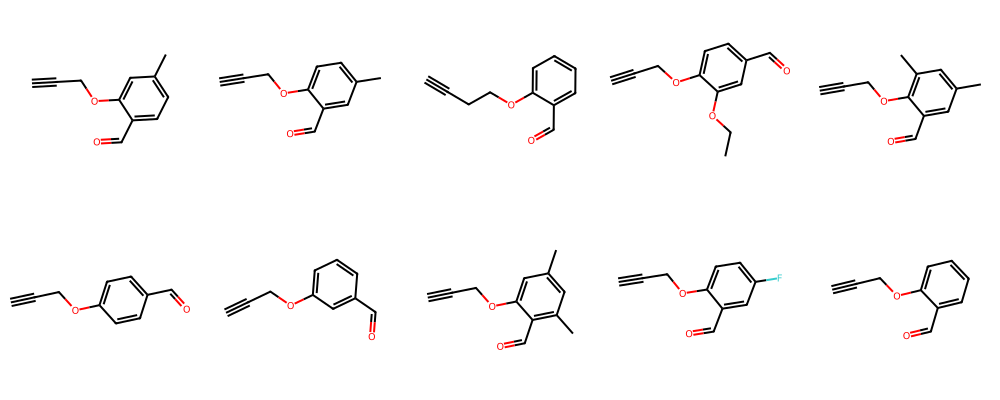

Cluster 10, n molecules: 103


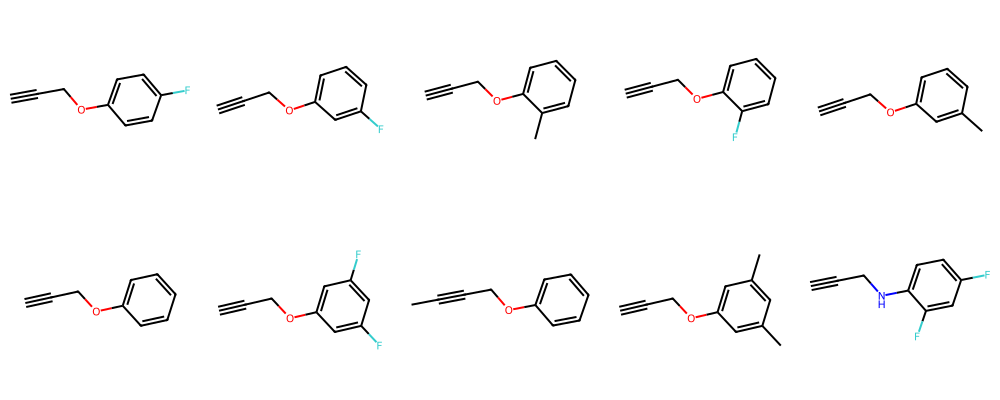

Cluster 11, n molecules: 102


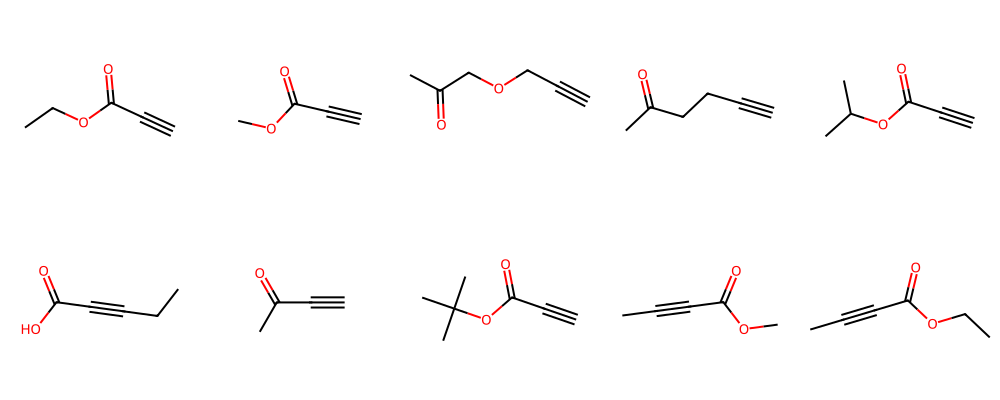

Cluster 12, n molecules: 117


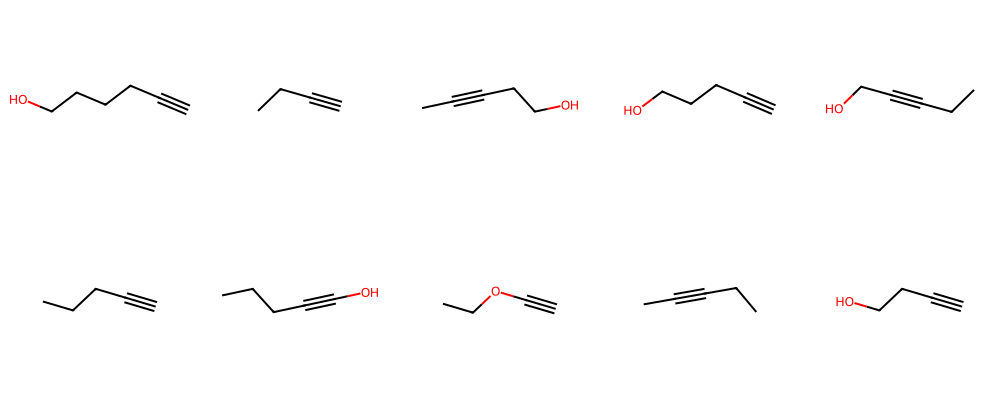

Cluster 13, n molecules: 106


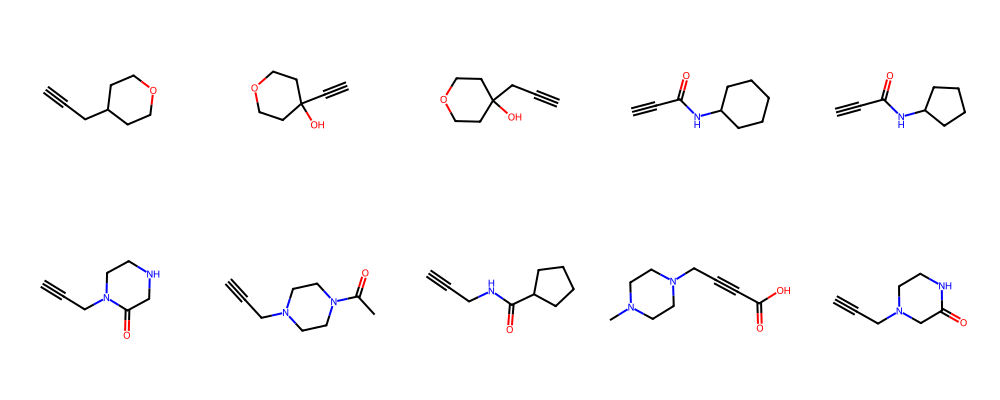

Cluster 14, n molecules: 71


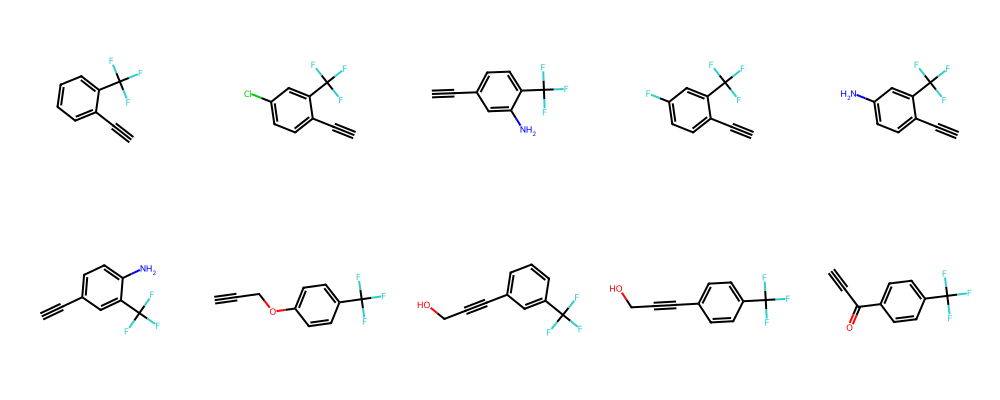

Cluster 15, n molecules: 70


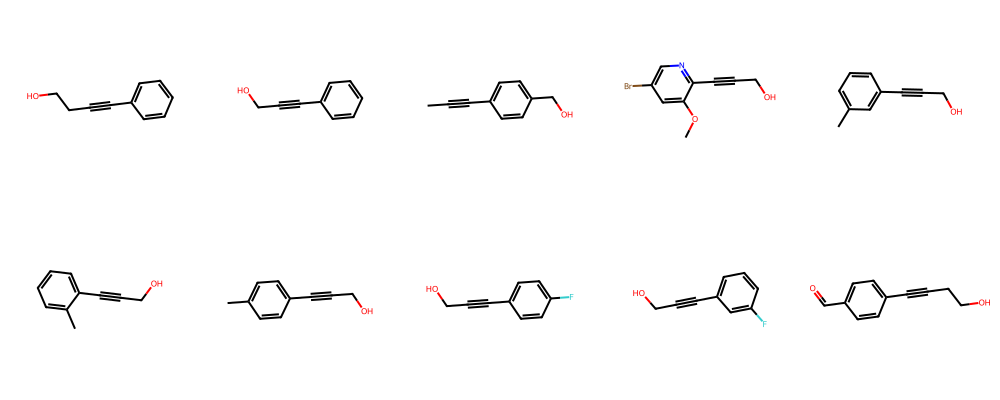

Cluster 16, n molecules: 66


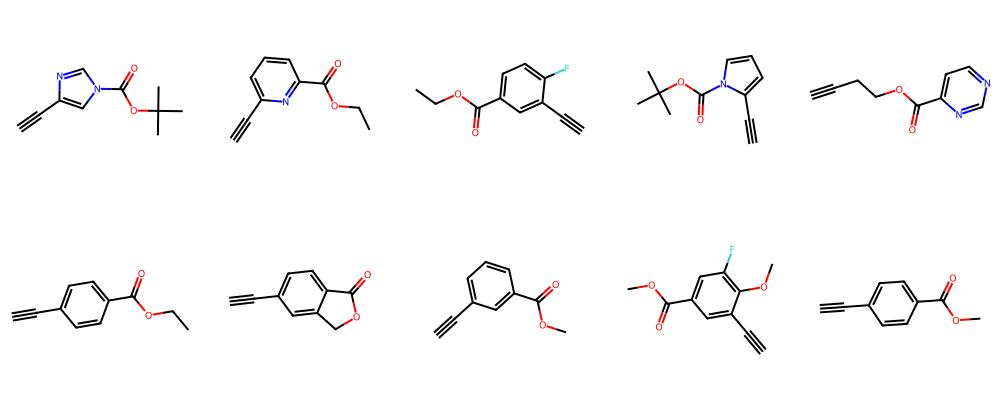

In [18]:
from scipy.spatial.distance import cdist
from rdkit.Chem import Draw
from rdkit import Chem

# build rdkit molecules for all candidates
mols = pd.Series(X_df.index.map(Chem.MolFromSmiles), index=X_df.index).to_frame('mol')

features='umap2'

# How many central molecules to display?
n_per_cluster = 10

# store central candidates for
cands=[]

for group, data in mols.groupby(cls):
    # get descriptor data for this cluster
    desc_data=dfs[features].loc[data.index]
    # compute distances of these molecules to their center
    dists=pd.Series(cdist([desc_data.mean()], desc_data)[0], index=desc_data.index)

    # select top n central molecules
    selected=dists.sort_values().head(n_per_cluster).index

    smi=mols.loc[selected]['mol'].map(Chem.MolToSmiles)
    smi=smi.reset_index(drop=True).to_frame(f"Cluster{group}")
    cands.append(smi)

    print (f"Cluster {group}, n molecules: {len(data)}")
    ms = data['mol'].loc[selected]
    display(Draw.MolsToGridImage(ms, molsPerRow=5))

cands = pd.concat(cands, axis=1)